In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math 
import pandas as pd
import os
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"

In [2]:
# Experiment data
data=np.loadtxt("20200410BEC3.txt",skiprows=1)
pixels=data[:,0]
y1=data[:,1]
y2=data[:,2]
y3=data[:,3]
yavg=data[:,4]
x1=data[:,5]
x2=data[:,6]
x3=data[:,7]
xavg=data[:,8]

FileNotFoundError: 20200410BEC3.txt not found.

In [ ]:
T_by_Tc=0.65
# mean trap frequency of the trap
wx=2*np.pi*30.8495634 ## Dimple 4.38 V Reservior 5.2V
wy=2*np.pi*150.7136784
wz=2*np.pi*150.7136784
wh0=(wx*wy*wz)**(1/3)
kb=1.380649e-23 # Boltzmann constant
hbar=1.054571817e-34 #hbar
m=87*1.6605e-27 # Rb mass
tof=15e-3 # TOF of imaging 8ms+7ms 
N=30000
# BEC critical temperature
Tc=(0.94*hbar*wh0*(N**(1/3)))/kb #Critical temperature
T=T_by_Tc*Tc # BEC Temperature
# Thermal size 
## Equation 2.23 of A. Harsono (Oxford) doctorate thesis 
sigma_cloudx=1/wx*np.sqrt(2*kb*T/m)*(1/np.sqrt(2)) # Cloud size in x: (multiplied (1/np.sqrt(2) to make 2*sigmna^2)
# Thermal size after TOF
sigma_xTh=np.sqrt(sigma_cloudx**2+(kb*T/m)*tof**2)# Thermal size after TOF in x

print("Tc =",np.round(Tc*1e9,2),"nk") #  Print critical temperature
print("Thermal size in x after 15ms TOF =", np.round(sigma_xTh*1e6,2), "um")

Tc = 124.51 nk
Thermal size in x after 15ms TOF = 44.11 um


In [ ]:
#Experimental data centered to 0 and positive y axis
pixels1=(pixels*6.25)*1e-6 # pixels to m
yavg1=yavg*(-1)
x_offset=pixels1[yavg1.argmax()]*1e6 # to find offset
pixels_center0=(pixels*6.25-x_offset)*1e-6 # x-axis xentered to 0

# NBEC and Nth from T_by_Tc
frac=1-T_by_Tc**(3) # BEC fraction
NBEC=frac*N # BEC atoms
Nth=N-NBEC # Thermal atoms

Peak ampitude =  0.8371478329110056
BEC width =  4.100237069854036e-05
Peak center =  -5.002580707254385e-06


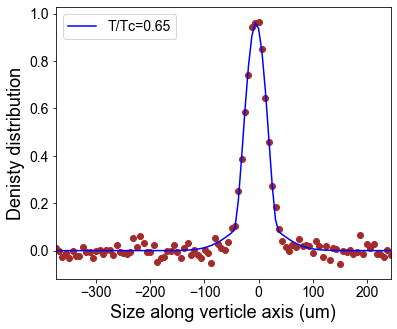

In [ ]:
def piecewise_BEC(x, BEC_peak,sigma_xBEC, x0): # fitting parameters, 1. BEC amplitude 2. BEC width 3. peak center
    condlist = [(x >= -sigma_xBEC+x0) & (x <= sigma_xBEC+x0), (x < -sigma_xBEC+x0), (x > sigma_xBEC+x0) ]
    funclist = [lambda x: BEC_peak*((1-((x-x0)/sigma_xBEC)**2)**2)+Nth/NBEC*BEC_peak/np.sqrt(2*np.pi)*16/15*sigma_xBEC/sigma_xTh*np.exp(-0.5*(((x-x0)/sigma_xTh)**2)),
                lambda x: Nth/NBEC*BEC_peak/np.sqrt(2*np.pi)*16/15*sigma_xBEC/sigma_xTh*np.exp(-0.5*(((x-x0)/sigma_xTh)**2)),
                lambda x: Nth/NBEC*BEC_peak/np.sqrt(2*np.pi)* 16/15*sigma_xBEC/sigma_xTh*np.exp(-0.5*(((x-x0)/sigma_xTh)**2))] 
    return np.piecewise(x, condlist, funclist)
initial_param=[1,30e-6,1e-6] 
bounds_param=((-np.inf,-np.inf,-np.inf),(np.inf,np.inf,np.inf))
param, cov = curve_fit(piecewise_BEC, pixels_center0, yavg1,p0=initial_param,bounds=bounds_param)
pixelPiece = np.linspace(min(pixels_center0),max(pixels_center0),100)
fig,ax=plt.subplots(figsize=(6,5))
ax.scatter(pixels_center0*1e6,yavg1,c='brown')
ax.plot(pixelPiece*1e6, piecewise_BEC(pixelPiece, *param),c='blue',label = "T/Tc=0.65")

ax.set_xlabel("Size along verticle axis (um)", fontsize = 18)
ax.set_ylabel("Denisty distribution", fontsize = 18)
ax.legend(loc="upper left", fontsize=14)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)

ax.set_xlim(min(pixels_center0)*1e6,max(pixels_center0)*1e6)

print("Peak ampitude = ", param[0])
print("BEC width = ",param[1])
print("Peak center = ",param[2])

plt.savefig("TbyTc_point65.pdf",transparent=True,bbox_inches="tight")


In [ ]:
#xres=np.round((pixelPiece,10)-np.round((pixels_center0,10)
yfit=piecewise_BEC(pixelPiece, *param)
yres=yfit-yavg1
yres_square=yres**2

yres_square_sum=0
for i in range(0, len(yres_square)):    
    yres_square_sum = yres_square_sum + yres_square[i];       
print("Sum of square of residuals = " + str(yres_square_sum))
# BEC fraction
print("BEC frac=",np.round(frac*100,2),"%")

#print(yres)

Sum of square of residuals = 0.06825194631253068
BEC frac= 72.54 %


Kink point = 0.648
Kink point = 0.663
Kink point = 0.669


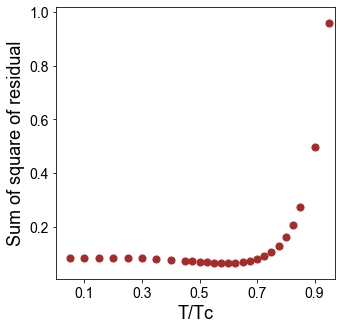

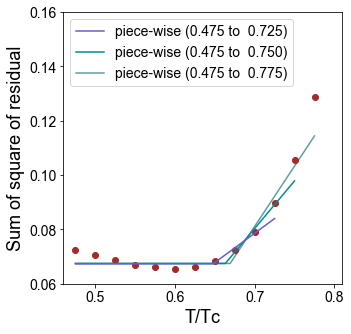

In [ ]:
T_by_Tc=[0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.475,
      0.5,0.525,0.55,0.575,0.6,0.625,0.65,0.675,0.7,0.725,
      0.75,0.775,0.8,0.825,0.85,0.9,0.95]

res_sq_sum=[0.0856,0.0855,0.0854,0.0850,0.0842,0.0827,0.0806,0.0777,0.0742,0.0723,
           0.0705,0.0687,0.0671,0.0660,0.0656,0.0662,0.0683,0.0723,0.0791,0.0898,
           0.1057,0.1286,0.1613,0.2076,0.2727,0.4968,0.9595]

fig,ax=plt.subplots(figsize=(5,5))
ax.scatter(T_by_Tc,res_sq_sum, c="brown", s = 50)
ax.set_xlabel("T/Tc", fontsize = 18)
ax.set_ylabel("Sum of square of residual", fontsize = 18)

ax.set_xticks([0.1,0.3,0.5,0.7,0.9])
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)

ax.set_xlim(0.0,0.97)


x1=0.475
x2=0.725
def piecewise_linear(x, x0, m, c): # peiece-wise function to only fit the peak by Thomas fermi 1D distribution 
    condlist = [(x > x1) & (x < x0) , (x >= x0) & (x < x2)]
    funclist = [lambda x: c, lambda x: m*(x-x0)+c] ##Function is normalized to 1 as experimental data
    return np.piecewise(x, condlist, funclist)
initial_param=[0.5,1,.01]
bounds_param=((-np.inf,-np.inf,-np.inf),(np.inf,np.inf,np.inf))
# Ploting BEC tempearature vs sum of square of residuals and BEC fraction
param, cov = curve_fit(piecewise_linear, T_by_Tc,res_sq_sum, p0=initial_param,bounds=bounds_param)
Piece = np.linspace(x1+.0001, x2-.0001, 1000)

fig,ax=plt.subplots(figsize=(5,5))
ax.scatter(T_by_Tc,res_sq_sum,c='brown')
ax.plot(Piece, piecewise_linear(Piece, *param),c='slateblue',linestyle='-',label='piece-wise (0.475 to  0.725)',zorder=2)
print("Kink point =", np.round(param[0],3))


x2=0.75
def piecewise_linear1(x, x0, m, c): # peiece-wise function to only fit the peak by Thomas fermi 1D distribution 
    condlist = [(x > x1) & (x < x0) , (x >= x0) & (x < x2)]
    funclist = [lambda x: c, lambda x: m*(x-x0)+c] ##Function is normalized to 1 as experimental data
    return np.piecewise(x, condlist, funclist)
initial_param=[0.5,1,.1]
bounds_param=((-np.inf,-np.inf,-np.inf),(np.inf,np.inf,np.inf))
# Ploting BEC tempearature vs sum of square of residuals and BEC fraction
param1, cov = curve_fit(piecewise_linear, T_by_Tc,res_sq_sum, p0=initial_param,bounds=bounds_param)
Piece1 = np.linspace(x1+.0001, x2-.0001, 1000)
ax.plot(Piece1, piecewise_linear1(Piece1, *param1),c='darkcyan',linestyle='-',label='piece-wise (0.475 to  0.750)',zorder=1)
print("Kink point =", np.round(param1[0],3))


x2=0.775
def piecewise_linear2(x, x0, m, c): # peiece-wise function to only fit the peak by Thomas fermi 1D distribution 
    condlist = [(x > x1) & (x < x0) , (x >= x0) & (x < x2)]
    funclist = [lambda x: c, lambda x: m*(x-x0)+c] ##Function is normalized to 1 as experimental data
    return np.piecewise(x, condlist, funclist)
initial_param=[0.5,1,.1]
bounds_param=((-np.inf,-np.inf,-np.inf),(np.inf,np.inf,np.inf))
# Ploting BEC tempearature vs sum of square of residuals and BEC fraction
param2, cov = curve_fit(piecewise_linear, T_by_Tc,res_sq_sum, p0=initial_param,bounds=bounds_param)
Piece2 = np.linspace(x1+.0001, x2-.0001, 1000)
ax.plot(Piece2, piecewise_linear2(Piece2, *param2),c='cadetblue',linestyle='-',label='piece-wise (0.475 to  0.775)',zorder=0)
print("Kink point =", np.round(param2[0],3))

ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)

ax.set_xlabel("T/Tc", fontsize = 18)
ax.set_ylabel("Sum of square of residual", fontsize = 18)

#ax.set_ylim(0.06,0.16)
#ax.set_xlim(0.38,0.72)
#ax.set_yticks([0.08,0.12,0.16])
#ax.set_xticks([0.4,0.5,0.6,0.7])
ax.legend(loc="upper left", fontsize=14)

#plt.savefig("BEC_piecewise.pdf",transparent=True,bbox_inches="tight")


ax.set_ylim(0.06,0.16)
ax.set_xlim(0.46,0.81)
#ax.set_yticks([0.08,0.12,0.16])
ax.set_xticks([0.5,0.6,0.7,0.8])
#ax.legend(loc="upper left", fontsize=14)

plt.savefig("BEC_piecewise1.pdf",transparent=True,bbox_inches="tight")


In [ ]:
# entropy # Equation 25 of RMP 71, 463 (1999)
kb=1.380649e-23 # Boltzmann constant
N=1
T_by_Tc=0.65
zeta3=1.2020569031595942853
zeta4=(np.pi**4)/90
#zeta4=1.082323233711138191516003696541
alpha=3
S=(alpha+1)*zeta4/zeta3*N*kb*((T_by_Tc)**alpha)
S_kb=(alpha+1)*zeta4/zeta3*N*((T_by_Tc)**alpha)
print("Entropy =",S, "J/K")
print("Entropy =",S_kb, "kb")
#print(zeta4)

Entropy = 1.3655741856146272e-23 J/K
Entropy = 0.9890813563871971 kb
